In [ ]:
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")

from sklearn.metrics import r2_score
from sklearn.preprocessing import QuantileTransformer

2025-02-12 03:11:28.642001: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739304688.652235 4091413 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739304688.655395 4091413 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-12 03:11:28.667133: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
data = np.loadtxt("tree_gg_bbh_5K.txt")
np.random.shuffle(data)
print(data.shape)


(5000, 7)


In [ ]:
train_split_ratio = 0.8
val_split_ratio = 0.1
train_split_count = int(data.shape[0] * train_split_ratio)
val_split_count = int(data.shape[0] * val_split_ratio)
num_features = data.shape[1] - 1

x = data[:, :num_features]
y = np.log(data[:, num_features:])

pt = QuantileTransformer()
pt = pt.fit(x[:train_split_count], y[:train_split_count])
x = pt.transform(x)

data = np.concatenate([x, y], axis=-1)

data_train = data[:train_split_count]
data_val = data[train_split_count:train_split_count + val_split_count]
data_test = data[train_split_count + val_split_count:]
print(data_train.shape)
print(data_val.shape)
print(data_test.shape)

x_train = data_train[:, :num_features]
y_train = data_train[:, num_features:]

x_val = data_val[:, :num_features]
y_val = data_val[:, num_features:]

x_test = data_test[:, :num_features]
y_test = data_test[:, num_features:]


print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(x_test.shape)
print(y_test.shape)


(4000, 7)
(500, 7)
(500, 7)
(4000, 6)
(4000, 1)
(500, 6)
(500, 1)
(500, 6)
(500, 1)


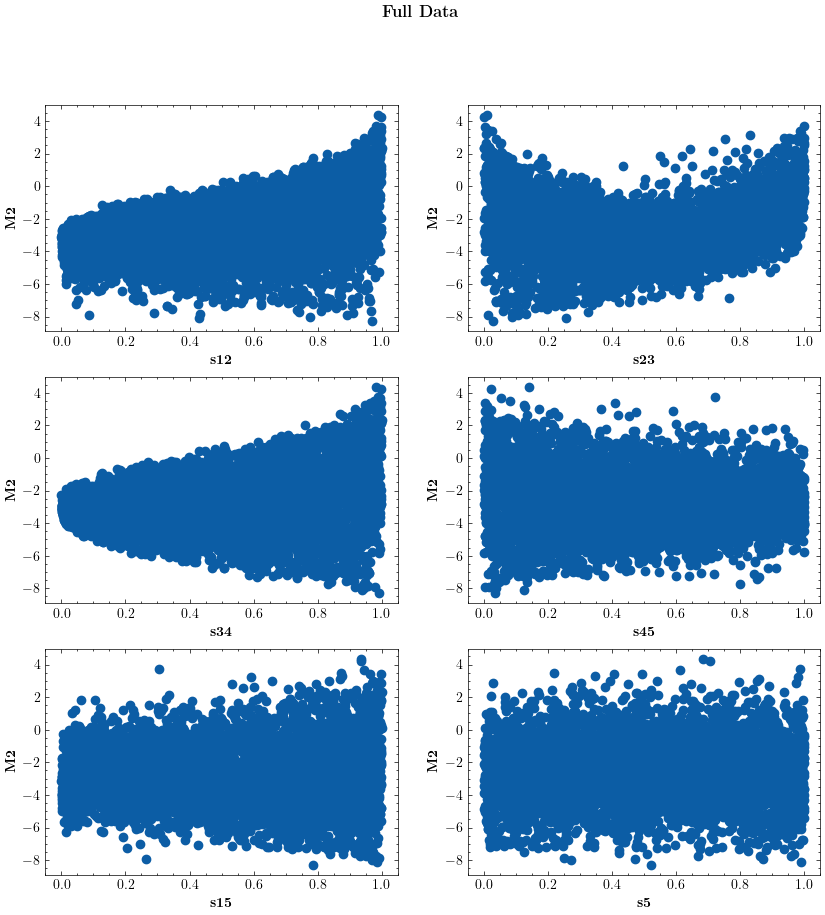

In [6]:
xlabel_map = {
    0 : r"\textbf{s12}",
    1 : r"\textbf{s23}",
    2 : r"\textbf{s34}",
    3 : r"\textbf{s45}",
    4 : r"\textbf{s15}",
    5 : r"\textbf{s5}",
}


fig, ax = plt.subplots(3, 2, figsize=(10, 10))
plt.suptitle(r"\textbf{Full Data}")

for i in range(num_features):
    row = int(i / 2)
    col = i % 2
    ax[row, col].set_xlabel(xlabel_map[i])
    ax[row, col].set_ylabel(r"\textbf{M2}")
    ax[row, col].scatter(data[:, i], data[:, num_features])
# plt.savefig("Images/Full-Data-Feature.png", dpi=300)



In [ ]:
def create_model(input_shape):
    input = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(1000)(input)
    x = tf.keras.layers.Dense(1000)(x)
    x = tf.keras.layers.Dense(1000)(x)
    x = tf.keras.layers.Dense(1000, activation='sigmoid')(x)
    x = tf.keras.layers.Dense(1000, activation='relu')(x)
    x = tf.keras.layers.Dense(1000, activation='relu')(x)
    x = tf.keras.layers.Dense(1000, activation='tanh')(x)
    x = tf.keras.layers.Dense(1000, activation='exponential')(x)
    x = tf.keras.layers.Dense(1000, activation='relu')(x)
    x = tf.keras.layers.Dense(1000, activation='sigmoid')(x)
    x = tf.keras.layers.Dense(1000, activation='relu')(x)
    x = tf.keras.layers.Dense(1000)(x)

    output = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inputs=input, outputs=output)

    return model



In [ ]:
input_shape = (num_features,)
model = create_model(input_shape)
model.summary()

2025-02-12 03:11:40.140042: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2025-02-12 03:11:40.140067: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: quasi07
2025-02-12 03:11:40.140073: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: quasi07
2025-02-12 03:11:40.140161: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 535.216.1
2025-02-12 03:11:40.140179: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 535.183.1
2025-02-12 03:11:40.140183: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:262] kernel version 535.183.1 does not match DSO version 535.216.1 -- cannot find working devices

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │         7,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │         1,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,019,001 (42.03 MB)

 Trainable params: 11,019,001 (42.03 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
loss = tf.keras.losses.MeanAbsoluteError()
model.compile(optimizer=optimizer, loss=loss)

In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', min_delta=1e-6, patience=100, restore_best_weights=True)
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), batch_size=1000, epochs=100000, callbacks=[early_stopping])

Epoch 1/100000


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - loss: 3.2555 - val_loss: 2.5199
Epoch 2/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - loss: 2.4042 - val_loss: 1.8907
Epoch 3/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 1.8408 - val_loss: 1.5712
Epoch 4/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - loss: 1.5864 - val_loss: 1.5336
Epoch 5/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - loss: 1.5532 - val_loss: 1.6031
Epoch 6/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - loss: 1.6127 - val_loss: 1.6220
Epoch 7/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - loss: 1.6493 - val_loss: 1.5773
Epoch 8/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 1.5869 - val_loss: 1.5344
Epoch 9/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - loss: 1.5586 - val_loss: 1.5200
Epoch 10/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 1.5502 - val_loss: 1.5255
Epoch 11/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 1.5582 - val_loss: 1.5276
Epoch 12/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 1

In [16]:
model.save("model.keras")

0.41600942611694336
0.47215181589126587


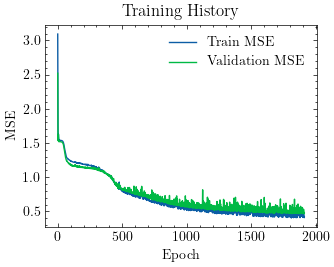

In [ ]:
losses = np.array(history.history['loss'])
val_losses = np.array(history.history['val_loss'])

plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.plot(np.arange(losses.shape[0]), losses, label="Train MSE")
plt.plot(np.arange(losses.shape[0]), val_losses, label="Validation MSE")
plt.legend()
# plt.savefig("Images/Full-Data-Train.png", dpi=300)

print(losses[-1])
print(val_losses[-1])

In [ ]:

y_train_pred = model.predict(x_train)[:, 0]
y_val_pred = model.predict(x_val)[:, 0]
y_test_pred = model.predict(x_test)[:, 0]


(4000, 6)
(4000, 1)
(500, 6)
(500, 1)
(500, 6)
(500, 1)
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


0.8534045534004795


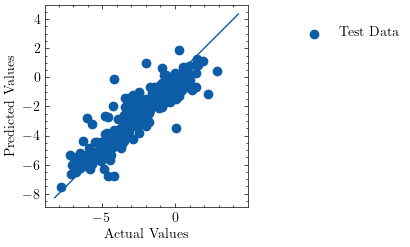

In [ ]:
min_ = np.min(np.concatenate((y_train[:, 0], y_val[:, 0], y_test[:, 0], y_train_pred, y_val_pred, y_test_pred)))
max_ = np.max(np.concatenate((y_train[:, 0], y_val[:, 0], y_test[:, 0], y_train_pred, y_val_pred, y_test_pred)))
# r2 = r2_score(np.concatenate((y_train[:, 0], y_val[:, 0], y_test[:, 0])), np.concatenate((y_train_pred, y_val_pred, y_test_pred)))
r2_test = r2_score(y_test, y_test_pred)

# plt.scatter(y_train[:, 0], y_train_pred, label="Train Data")
# plt.scatter(y_val[:, 0], y_val_pred, label="Validation Data")
plt.scatter(y_test[:, 0], y_test_pred, label="Test Data")
plt.plot([min_, max_], [min_, max_])

# print(r2)
print(f"r2 score : {r2_test}")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.legend(bbox_to_anchor=(1.2, 0.95))

ax = plt.gca()
ax.set_aspect('equal', adjustable='box')